In [1]:
import numpy as np
from PIL import Image, UnidentifiedImageError
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import pairwise_distances_argmin_min
from tensorflow.keras.callbacks import ReduceLROnPlateau
import os, json, time

IMG_SIZE = (150, 150)

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 3e-5

DINO_FOLDER = "dataset/dinosaur"
NON_DINO_FOLDER = "dataset/not_dinosaur"

MODEL_PATH = "models/stage1_binary.keras"

Завантажуємо наші картинки з динозаврами


In [ ]:
CACHE_X = "dataset/cache_X.npy"
CACHE_Y = "dataset/cache_Y.npy"

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y):
    X = np.load(CACHE_X)
    y = np.load(CACHE_Y)
    # migrate old float32 cache (0–1) to uint8 (0–255) to cut RAM 4×
    if X.dtype != np.uint8:
        X = (X * 255).astype(np.uint8)
    dino_images     = X[y == 1]
    not_dino_images = X[y == 0]
    SKIP_LOADING = True
    print(f"Завантажено з кешу: {X.shape} dtype={X.dtype}")
    print(f"Динозаврів: {(y==1).sum()}, Не-динозаврів: {(y==0).sum()}")
else:
    SKIP_LOADING = False
    print("Кеш не знайдено — завантажуємо зображення з диску")

In [3]:
if not SKIP_LOADING:
    dino_paths = glob("dataset/dinosaur/**/*.*", recursive=True)
    dino_images = []

    for path in tqdm(dino_paths, desc="Завантаження динозаврів"):
        try:
            img = Image.open(path).convert("RGB").resize(IMG_SIZE)
            dino_images.append(np.array(img))
        except (UnidentifiedImageError, OSError):
            print(f"Пропускаємо файл: {path}")

    dino_images = np.array(dino_images)
    dino_labels = np.ones(len(dino_images), dtype=np.int32)
    print("Готово! Завантажено динозаврів:", dino_images.shape)

from PIL import Image, UnidentifiedImageError

Завантаження динозаврів:   5%|▌         | 691/12621 [00:17<03:29, 56.99it/s] c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Завантаження динозаврів:  44%|████▍     | 5543/12621 [02:44<00:56, 126.27it/s]

Пропускаємо файл: dataset/dinosaur\Giganotosaurus\Giganotosaurus_002.jpg
Пропускаємо файл: dataset/dinosaur\Giganotosaurus\Giganotosaurus_018.jpg


Завантаження динозаврів:  73%|███████▎  | 9211/12621 [04:43<00:40, 84.95it/s] 

Пропускаємо файл: dataset/dinosaur\Saurornithoides\Saurornithoides_012.jpg


Завантаження динозаврів: 100%|██████████| 12621/12621 [07:07<00:00, 29.50it/s]


Готово! Завантажено динозаврів: (12618, 150, 150, 3)


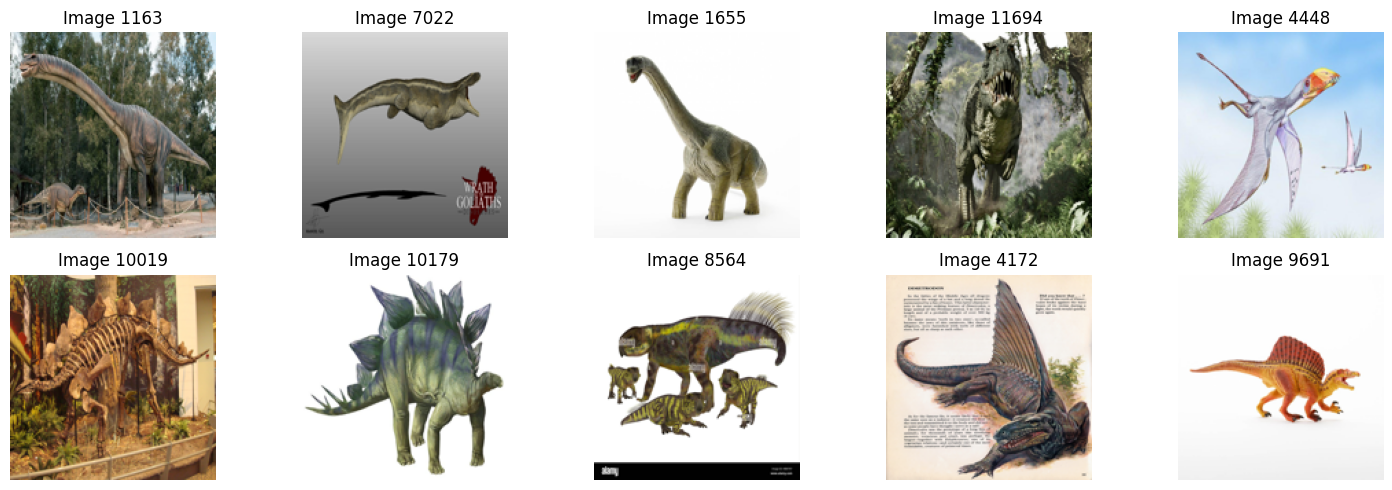

In [4]:
import random
import matplotlib.pyplot as plt

num_show = 10

indices = random.sample(range(len(dino_images)), num_show)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(dino_images[idx])
    plt.axis('off')
    plt.title(f"Image {idx}")

plt.tight_layout()
plt.show()

Завантаження 'Не динозаврів'


In [5]:
if not SKIP_LOADING:
    from PIL import Image, UnidentifiedImageError

    not_dino_paths = glob("dataset/not_dinosaur/**/*.*", recursive=True)
    not_dino_images = []

    for path in tqdm(not_dino_paths, desc="Завантаження не-динозаврів"):
        try:
            img = Image.open(path).convert("RGB").resize(IMG_SIZE)
            not_dino_images.append(np.array(img))
        except (UnidentifiedImageError, OSError):
            print(f"Пропускаємо файл: {path}")

    not_dino_images = np.array(not_dino_images)
    not_dino_labels = np.zeros(len(not_dino_images), dtype=np.int32)
    print("Готово! Завантажено не-динозаврів:", not_dino_images.shape)

Завантаження не-динозаврів:  43%|████▎     | 7384/17131 [02:24<02:54, 55.87it/s] 

Пропускаємо файл: dataset/not_dinosaur\Dog\Thumbs.db


Завантаження не-динозаврів:  74%|███████▎  | 12600/17131 [04:39<01:40, 45.04it/s]


KeyboardInterrupt: 

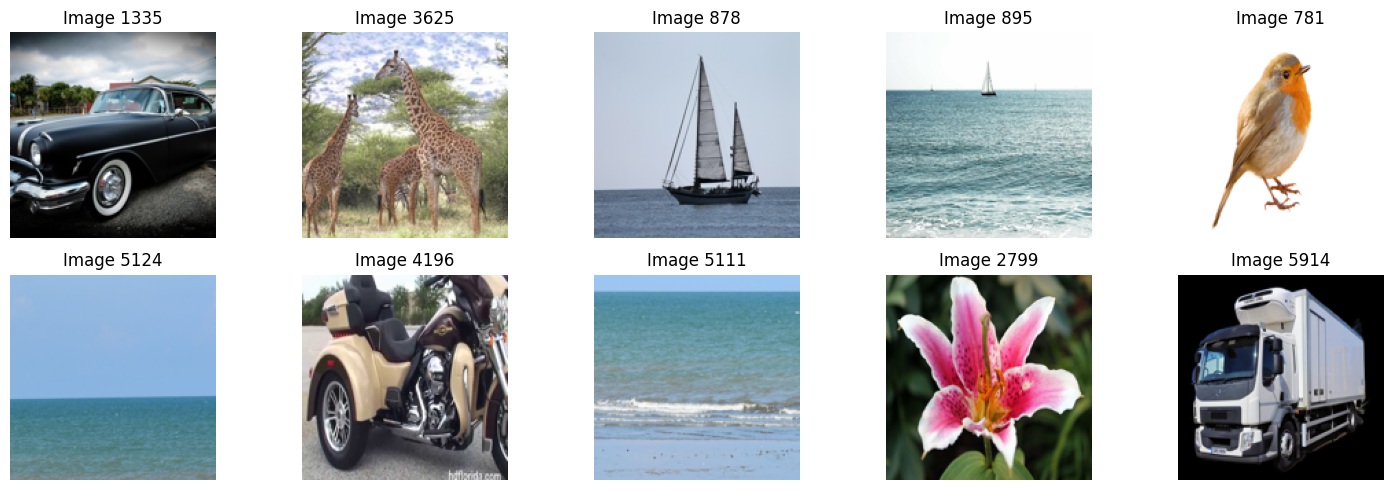

In [ ]:
import random
import matplotlib.pyplot as plt

num_show = 10

indices = random.sample(range(len(not_dino_images)), num_show)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(not_dino_images[idx])
    plt.axis('off')
    plt.title(f"Image {idx}")

plt.tight_layout()
plt.show()

Створення фінального дадасету


In [ ]:
if not SKIP_LOADING:
    # keep uint8 (0–255) — generator rescales to float32 per-batch, saving ~6 GB RAM
    X = np.concatenate([dino_images, not_dino_images], axis=0)
    y = np.concatenate([dino_labels, not_dino_labels], axis=0)

    os.makedirs("dataset", exist_ok=True)
    np.save(CACHE_X, X)
    np.save(CACHE_Y, y)
    print(f"Кеш збережено: {CACHE_X}, {CACHE_Y}")

print("Фінальний датасет:", X.shape, y.shape, X.dtype)

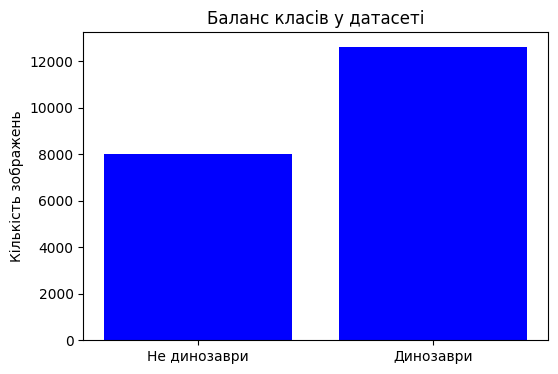

Клас 0: 8025 зображень
Клас 1: 12618 зображень


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(['Не динозаври', 'Динозаври'], counts, color=['blue', 'blue'])
plt.title("Баланс класів у датасеті")
plt.ylabel("Кількість зображень")
plt.show()

for u, c in zip(unique, counts):
    print(f"Клас {u}: {c} зображень")

Підготовка даних до навчання


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

Створення генераторів


In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_flow = val_gen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Class weights


In [ ]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, class_weights_array))

Створення CNN моделі


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model

model = create_model()
model.summary()


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,712,513 (40.86 MB)

 Trainable params: 10,711,553 (40.86 MB)

 Non-trainable params: 960 (3.75 KB)

Callbacks


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

Запуск


In [ ]:
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/30
452/452 - 574s - 1s/step - accuracy: 0.7272 - auc: 0.8371 - loss: 0.5237 - precision: 0.8809 - recall: 0.6403 - val_accuracy: 0.7494 - val_auc: 0.8801 - val_loss: 0.5338 - val_precision: 0.9195 - val_recall: 0.6464 - learning_rate: 3.0000e-05
Epoch 2/30
452/452 - 545s - 1s/step - accuracy: 0.7891 - auc: 0.8826 - loss: 0.4309 - precision: 0.8813 - recall: 0.7570 - val_accuracy: 0.8337 - val_auc: 0.9247 - val_loss: 0.3795 - val_precision: 0.9355 - val_recall: 0.7817 - learning_rate: 3.0000e-05
Epoch 3/30
452/452 - 497s - 1s/step - accuracy: 0.8195 - auc: 0.9039 - loss: 0.3912 - precision: 0.8928 - recall: 0.8009 - val_accuracy: 0.8453 - val_auc: 0.9322 - val_loss: 0.3384 - val_precision: 0.8344 - val_recall: 0.9318 - learning_rate: 3.0000e-05
Epoch 4/30
452/452 - 564s - 1s/step - accuracy: 0.8270 - auc: 0.9125 - loss: 0.3735 - precision: 0.8944 - recall: 0.8130 - val_accuracy: 0.8285 - val_auc: 0.9309 - val_loss: 0.4048 - val_precision: 0.9410 - val_recall: 0.7674 - learning_r

In [ ]:
model.save(MODEL_PATH)
print(f"Модель збережена за шляхом: {MODEL_PATH}")

Модель збережена за шляхом: models/stage1_binary.keras


Візуалізація


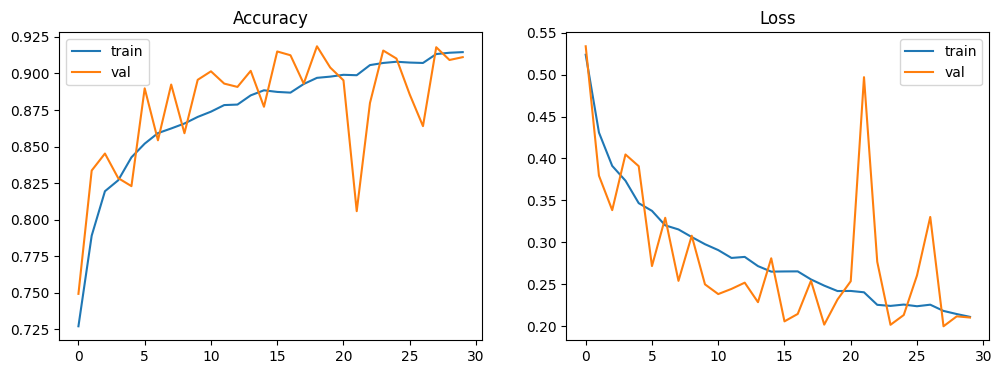

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
X_test_norm = X_test.astype('float32') / 255.0

y_pred_prob = model.predict(X_test_norm, batch_size=BATCH_SIZE)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Не динозавр", "Динозавр"])
disp.plot(cmap="Blues")

plt.title("Матриця плутанини")
plt.show()

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

class_names = ["Не динозавр", "Динозавр"]

indices = random.sample(range(len(X_test)), 10)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = int(y_test[idx])

    img_norm = img.astype('float32') / 255.0
    pred_prob = model.predict(img_norm.reshape(1, IMG_SIZE[0], IMG_SIZE[1], 3), verbose=0)[0][0]
    pred_label = int(pred_prob >= 0.5)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Істинний: {class_names[true_label]}\nПередбачений: {class_names[pred_label]}\n({pred_prob:.2f})", fontsize=10)

plt.tight_layout()
plt.show()

## Grad-CAM — пояснення рішень моделі

In [ ]:
def make_gradcam_heatmap(img_array, model):
    last_conv = next(l for l in reversed(model.layers) if isinstance(l, tf.keras.layers.Conv2D))
    grad_model = tf.keras.models.Model(
        model.inputs,
        [last_conv.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        score = preds[:, 0]
    grads        = tape.gradient(score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_norm, heatmap, alpha=0.45):
    original   = (img_norm * 255).astype(np.uint8)
    hm_resized = np.array(
        Image.fromarray(np.uint8(255 * heatmap)).resize(
            (original.shape[1], original.shape[0]), Image.LANCZOS
        )
    )
    colored = plt.cm.jet(hm_resized / 255.0)[:, :, :3]
    blended = colored * alpha + original / 255.0 * (1 - alpha)
    return original, np.clip(blended, 0, 1)

In [ ]:
y_test_prob = model.predict(X_test_norm, batch_size=BATCH_SIZE).flatten()

high_conf = np.where((y_test == 1) & (y_test_prob > 0.8))[0]
if len(high_conf) == 0:
    high_conf = np.where(y_test == 1)[0]

sample_idx = high_conf[:4]
n = len(sample_idx)

fig, axes = plt.subplots(n, 3, figsize=(13, 4 * n))
if n == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(sample_idx):
    img_arr = X_test_norm[idx:idx + 1]
    prob    = float(y_test_prob[idx])
    heatmap = make_gradcam_heatmap(img_arr, model)
    orig, blended = overlay_gradcam(X_test_norm[idx], heatmap)

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"Оригінал\nВпевненість: {prob:.1%}", fontsize=11)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(heatmap, cmap="jet")
    axes[row, 1].set_title("Grad-CAM", fontsize=11)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(blended)
    axes[row, 2].set_title("Overlay", fontsize=11)
    axes[row, 2].axis("off")

plt.suptitle("Grad-CAM: Чому модель вважає це динозавром?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()